# Library comparisson with BitBirch

Authors: Kenneth Lopez-Perez (klopezperez@ufl.edu) and Ramon Miranda-Quintana (quintana@chem.ufl.edu)

This notebook shows examples on how to compare two libraries to identify regions of the chemical space they have in common, and what regions they do not share.
This examples is suitable for libraries up to 10^6 cardinality at most, for bigger libraries we recommend a step-wise approach using the command line. For guidance, please follow the tutorial on command line usage.


In [1]:
from iChem.libcomp import LibChem, LibComparison
from iChem.utils import binary_fps, load_smiles
from iChem.cluster_sampling import bitbirch_sampling
from bblean import BitBirch
from iChem.visualization import *
import numpy as np
import warnings
np.random.seed(42)
warnings.filterwarnings('ignore')

## Clustering of the libraries and selection of representatives

First we are going to cluster the libraries and select the representatives from it. For the first library we will do it step by step, but then we will do it using the function that automatically does everything.

There are two possible sampling methods. 

'medoids' selects the medoid from each cluster
'centroid-like' selects the closest molecule to the centroid in the cluster

For both, if the cluster size is over 1_000, an approximation is done. A random sample of 1_000 molecules is taken and the medoid or centroid-like is compute with those only. This minimum number is adjustable to user needs with the `sample_min_size` parameter.

In this example, we will use 'medoids' first.

In [2]:
macrocycles_samples, macrocycles_cluster_sizes = bitbirch_sampling(smiles=load_smiles('../tests/data/mcule_macrocycles.smi'),
                                      threshold=0.3,
                                      branching_factor=10_000,
                                      merge_criterion='diameter',
                                      return_sizes=True,
                                      sample_min_size=1_000)

np_samples, np_cluster_sizes = bitbirch_sampling(smiles=load_smiles('../tests/data/mcule_natural_products.smi'),
                                      threshold=0.3,
                                      branching_factor=10_000,
                                      merge_criterion='diameter',
                                      return_sizes=True)

np_derivatives_samples, np_derivatives_cluster_sizes = bitbirch_sampling(smiles=load_smiles('../tests/data/mcule_natural_products_derivatives.smi'),
                                      threshold=0.3,
                                      branching_factor=10_000,
                                      merge_criterion='diameter',
                                      return_sizes=True)

Number of molecules in the file: 163427
Using sequential clustering for the file.


Sampling medoids: 100%|██████████| 291/291 [00:00<00:00, 1583064.16it/s]


Number of molecules in the file: 23327
Using sequential clustering for the file.


Sampling medoids: 100%|██████████| 1442/1442 [00:00<00:00, 3184932.26it/s]


Number of molecules in the file: 109173
Using sequential clustering for the file.


Sampling medoids: 100%|██████████| 1552/1552 [00:00<00:00, 3561028.34it/s]


Here we are going to create LibChem objects for each of the libraries we are going to compare. We are going to load the smiles and generate ECFP4 fingerprints to represent the molecules. 

We are going to compare mcule libraries. For download of this libraries please refer to https://mcule.com/database/.

In [3]:
Lib1 = LibChem(name='Macrocycles',
               smiles=macrocycles_samples)
Lib1.generate_fingerprints(fp_type='ECFP4', n_bits=2048)
Lib1.load_cluster_sizes(macrocycles_cluster_sizes)

Lib2 = LibChem(name='NPs',
               smiles=np_samples)
Lib2.generate_fingerprints(fp_type='ECFP4', n_bits=2048)
Lib2.load_cluster_sizes(np_cluster_sizes)


Lib3 = LibChem(name='NPs derivatives',
               smiles=np_derivatives_samples)
Lib3.generate_fingerprints(fp_type='ECFP4', n_bits=2048)
Lib3.load_cluster_sizes(np_derivatives_cluster_sizes)


Let's check the number.

In [4]:
print('Library 1 molecules:', f'{Lib1.n_molecules:,}')
print('Library 2 molecules:', f'{Lib2.n_molecules:,}')
print('Library 3 molecules:', f'{Lib3.n_molecules:,}')

Library 1 molecules: 291
Library 2 molecules: 1,442
Library 3 molecules: 1,552


In [5]:
print(
    'Total representatives:', f'{Lib1.n_molecules + Lib2.n_molecules + Lib3.n_molecules:,}'
)

Total representatives: 3,285


Now, we create a library comparison instance. Where we add each of the previously created libraries.

In [6]:
LibComp = LibComparison(Lib1, Lib2, Lib3)

Here we cluster the libraries together and get the fractions of clusters they share. That is of the representatives. With this number we can get an idea on how many chemotypes libraries share. If someone wants to know how many molecules or what fraction of molecules are in this shared area, they can set `representatives_only` as `False`. This will give different results as it answers a different question.

Clustering libraries together: Macrocycles, NPs, NPs derivatives
Number of molecules in the file: 3285
Using sequential clustering for the file.


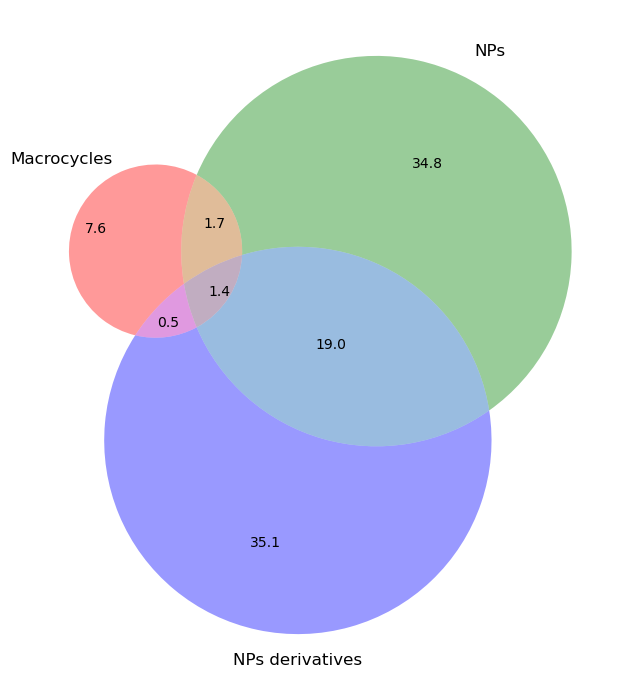

In [7]:
LibComp.cluster_libraries(threshold=0.3, branching_factor=10_000, merge_criterion='diameter')
LibComp.venn_diagram_overlap(percentages=True,
                           representatives_only=True)

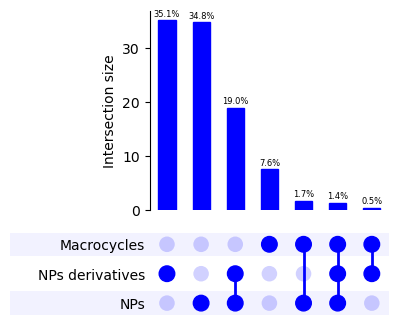

In [8]:
LibComp.upset_plot_overlap(percentages=True,
                           representatives_only=True,)

Clustering libraries together: Macrocycles, NPs
Number of molecules in the file: 1733
Using sequential clustering for the file.
Clustering libraries together: Macrocycles, NPs derivatives
Number of molecules in the file: 1843
Using sequential clustering for the file.
Clustering libraries together: NPs, NPs derivatives
Number of molecules in the file: 2994
Using sequential clustering for the file.


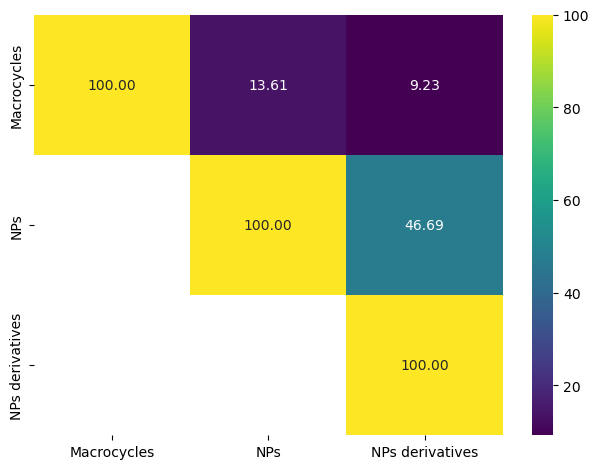

In [9]:
LibComp.compare_all_heatmap(methodology='shared-clusters',
                            representatives_only=False,)

Let's take a look at some of the cluster with exclusive and shared chemotypes.
For this we will access the `overlap_mapping` in the clustering results. Here we get what clusters are shared or exclusive to a database.

In [10]:
results = LibComp.get_cluster_results(overlap_mapping=True)
print(results['overlap_mapping'].keys())

dict_keys(['NPs+NPs derivatives', 'Macrocycles', 'Macrocycles+NPs+NPs derivatives', 'NPs derivatives', 'Macrocycles+NPs derivatives', 'NPs', 'Macrocycles+NPs'])


So for example, if we want to see chemotypes shared by the three libraries we call the results for that key.

In [13]:
print('Shared clusters', f'{results["overlap_mapping"]["NPs+NPs derivatives"]}')

Shared clusters [0, 1, 5, 6, 8, 9, 10, 11, 12, 14, 15, 16, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 30, 31, 32, 33, 43, 44, 45, 46, 47, 48, 49, 50, 54, 55, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 71, 72, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 101, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 142, 143, 144, 145, 146, 147, 148, 149, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 180, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 240, 241, 242, 243, 244, 245, 247, 248, 249, 250, 252, 253, 254, 255, 257, 258, 259, 261, 262, 263, 264, 266, 267, 268, 269, 314, 315, 316, 317, 318, 320, 321, 323, 324, 326, 327, 329, 330, 331, 333, 334, 335, 336, 338, 339, 340, 341, 342, 343, 347, 348, 349, 350, 3

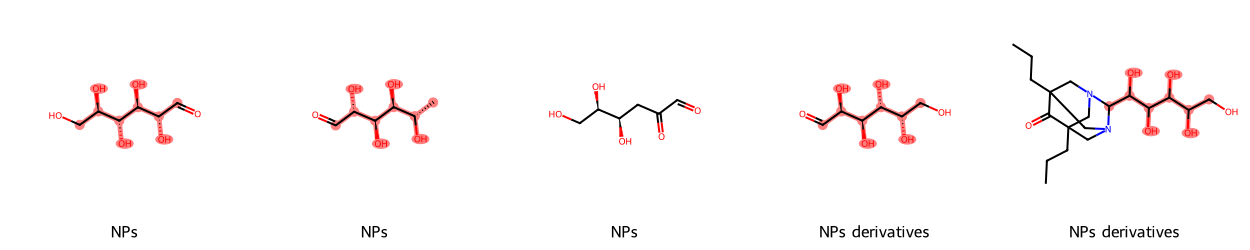

In [16]:
LibComp.display_cluster_molecules(cluster_id = 60)